In [4]:
import pandas as pd
import numpy as np

# 1. Load the specific sheet for "Share of GDP"
# Note: SIPRI files usually have a header. Adjust 'header' row if needed (usually row 5 or 6)
# We use the 'Share of GDP' sheet to see the economic burden.
sipri_df = pd.read_excel(
    "SIPRI-Milex-data-1949-2024_2.xlsx",
    sheet_name="Share of GDP",
    header=5  # Skip the first 5 rows of text descriptions
)

# 2. Filter for Soviet & Post-Soviet States
target_countries = [
    "USSR", "Russia", "Ukraine", "Belarus", "Uzbekistan", "Kazakhstan",
    "Georgia", "Azerbaijan", "Lithuania", "Moldova", "Latvia",
    "Kyrgyzstan", "Tajikistan", "Armenia", "Turkmenistan", "Estonia"
]

# Filter rows where 'Country' column matches our list
sipri_df = sipri_df[sipri_df['Country'].isin(target_countries)]

# 3. Clean the data (Melt from Wide to Long)
# Current format: Country | 1949 | 1950 | ... | 2023
# Desired format: Country | Year | Milex_Share_GDP
sipri_long = sipri_df.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Military_Exp_Percent_GDP'
)

# Convert Year to integer and handle "..." or "xxx" which SIPRI uses for missing data
sipri_long['Year'] = pd.to_numeric(sipri_long['Year'], errors='coerce')
sipri_long['Military_Exp_Percent_GDP'] = pd.to_numeric(sipri_long['Military_Exp_Percent_GDP'], errors='coerce')

# Drop empty rows
sipri_long = sipri_long.dropna(subset=['Year'])

print(f"SIPRI Data Loaded: {len(sipri_long)} rows")
print(sipri_long.head())


SIPRI Data Loaded: 1140 rows
         Country    Year  Military_Exp_Percent_GDP
15    Kazakhstan  1949.0                       NaN
16    Tajikistan  1949.0                       NaN
17  Turkmenistan  1949.0                       NaN
18    Uzbekistan  1949.0                       NaN
19       Estonia  1949.0                       NaN


In [5]:
sipri_long

,Country,Year,Military_Exp_Percent_GDP
15,Kazakhstan,1949.0,NaN
16,Tajikistan,1949.0,NaN
17,Turkmenistan,1949.0,NaN
18,Uzbekistan,1949.0,NaN
19,Estonia,1949.0,NaN
...,...,...,...
1150,Georgia,2024.0,0.018640
1151,Moldova,2024.0,0.005978
1152,Russia,2024.0,0.070523
1153,Ukraine,2024.0,0.344815


In [6]:
sipri_long = sipri_long.dropna()
print(sipri_long.shape)
sipri_long.head()

(397, 3)


,Country,Year,Military_Exp_Percent_GDP
661,Tajikistan,1992.0,0.000004
667,Armenia,1992.0,0.022034
668,Azerbaijan,1992.0,0.024002
669,Belarus,1992.0,0.016225
672,Russia,1992.0,0.044270


In [7]:
pip install wbgapi

In [8]:
import wbgapi as wb

# 1. Define the ISO-3 Codes for the Republics
# Note: World Bank doesn't have a "USSR" code for historical data,
# so we focus on the 15 republics to see the aftermath.
country_codes = [
    'RUS', 'UKR', 'BLR', 'UZB', 'KAZ', 'GEO', 'AZE', 'LTU',
    'MDA', 'LVA', 'KGZ', 'TJK', 'ARM', 'TKM', 'EST'
]

# 2. Fetch Data (GDP Per Capita, Constant 2015 US$)
# Indicator Code: NY.GDP.PCAP.KD
wb_data = wb.data.DataFrame(
    'NY.GDP.PCAP.KD',
    country_codes,
    time=range(1985, 2024), # Get data from before and after the fall
    labels=True # Includes Country Name column
).reset_index()

# 3. Clean World Bank Data (Melt Wide to Long)
# WBGAPI returns years as columns (YR1990, YR1991...), so we fix that.
wb_long = wb_data.melt(
    id_vars=['economy', 'Country'],
    var_name='Year',
    value_name='GDP_Per_Capita'
)

# Clean Year column (remove 'YR')
wb_long['Year'] = wb_long['Year'].str.replace('YR', '').astype(int)

# Rename 'economy' to 'ISO_Code' for clarity
wb_long = wb_long.rename(columns={'economy': 'ISO_Code'})

print(f"World Bank Data Loaded: {len(wb_long)} rows")
print(wb_long.head())


World Bank Data Loaded: 585 rows
  ISO_Code          Country  Year  GDP_Per_Capita
0      EST          Estonia  1985             NaN
1      TKM     Turkmenistan  1985             NaN
2      ARM          Armenia  1985             NaN
3      TJK       Tajikistan  1985     1417.668222
4      KGZ  Kyrgyz Republic  1985             NaN


In [9]:
wb_long

,ISO_Code,Country,Year,GDP_Per_Capita
0,EST,Estonia,1985,NaN
1,TKM,Turkmenistan,1985,NaN
2,ARM,Armenia,1985,NaN
3,TJK,Tajikistan,1985,1417.668222
4,KGZ,Kyrgyz Republic,1985,NaN
...,...,...,...,...
580,KAZ,Kazakhstan,2023,11453.395273
581,UZB,Uzbekistan,2023,3725.674146
582,BLR,Belarus,2023,6497.784507
583,UKR,Ukraine,2023,2164.261230


In [10]:
wb_long = wb_long.dropna()
print(wb_long.shape)
wb_long.head()

(534, 4)


,ISO_Code,Country,Year,GDP_Per_Capita
3,TJK,Tajikistan,1985,1417.668222
9,GEO,Georgia,1985,4688.071865
18,TJK,Tajikistan,1986,1420.201978
19,KGZ,Kyrgyz Republic,1986,1022.866604
24,GEO,Georgia,1986,4266.724946


In [11]:
# 1. Create a Mapping Dictionary (SIPRI Name -> ISO Code)
country_map = {
    "Russia": "RUS", "Ukraine": "UKR", "Belarus": "BLR", "Uzbekistan": "UZB",
    "Kazakhstan": "KAZ", "Georgia": "GEO", "Azerbaijan": "AZE", "Lithuania": "LTU",
    "Moldova": "MDA", "Latvia": "LVA", "Kyrgyzstan": "KGZ", "Tajikistan": "TJK",
    "Armenia": "ARM", "Turkmenistan": "TKM", "Estonia": "EST",
    # Note: "USSR" from SIPRI won't match a WB code, but we keep it for the chart
    "USSR": "USSR"
}

# Apply mapping to SIPRI data
sipri_long['ISO_Code'] = sipri_long['Country'].map(country_map)

# 2. Merge Datasets
# We do a "Left Join" on the SIPRI data because we want to keep the USSR military data
# even if it doesn't have matching World Bank GDP data.
final_df = pd.merge(
    sipri_long,
    wb_long[['ISO_Code', 'Year', 'GDP_Per_Capita']],
    on=['ISO_Code', 'Year'],
    how='left'
)

# 3. Feature Engineering (Qualitative Variable)
# Create a "Period" variable
def categorize_period(year):
    if year < 1991:
        return "Soviet Era"
    elif 1991 <= year <= 1999:
        return "Transitional Chaos"
    else:
        return "Recovery"

final_df['Period'] = final_df['Year'].apply(categorize_period)

# Save to CSV for your project submission/record
final_df.to_csv("soviet_breakdown_dataset.csv", index=False)
print("Dataset merged and saved!")


Dataset merged and saved!


/tmp/ipython-input-77199716.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sipri_long['ISO_Code'] = sipri_long['Country'].map(country_map)


In [12]:
final_df

,Country,Year,Military_Exp_Percent_GDP,ISO_Code,GDP_Per_Capita,Period
0,Tajikistan,1992.0,0.000004,TJK,827.586885,Transitional Chaos
1,Armenia,1992.0,0.022034,ARM,840.205259,Transitional Chaos
2,Azerbaijan,1992.0,0.024002,AZE,2141.340038,Transitional Chaos
3,Belarus,1992.0,0.016225,BLR,2573.299551,Transitional Chaos
4,Russia,1992.0,0.044270,RUS,6345.912109,Transitional Chaos
...,...,...,...,...,...,...
392,Belarus,2024.0,0.020736,BLR,NaN,Recovery
393,Georgia,2024.0,0.018640,GEO,NaN,Recovery
394,Moldova,2024.0,0.005978,MDA,NaN,Recovery
395,Russia,2024.0,0.070523,RUS,NaN,Recovery


In [19]:
final_df = final_df.dropna()
print(final_df.shape)
final_df.head()

(385, 7)


,Country,Year,Military_Exp_Percent_GDP,ISO_Code,GDP_Per_Capita,Period,Region
0,Tajikistan,1992.0,0.000004,TJK,827.586885,Transitional Chaos,Central Asia
1,Armenia,1992.0,0.022034,ARM,840.205259,Transitional Chaos,Caucasus
2,Azerbaijan,1992.0,0.024002,AZE,2141.340038,Transitional Chaos,Caucasus
3,Belarus,1992.0,0.016225,BLR,2573.299551,Transitional Chaos,Eastern Europe
4,Russia,1992.0,0.044270,RUS,6345.912109,Transitional Chaos,Eastern Europe


In [14]:
final_df.Country.value_counts()

,count
Country,
Belarus,32
Azerbaijan,32
Russia,32
Armenia,31
Kazakhstan,31
Estonia,31
Ukraine,31
Latvia,31
Lithuania,31


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df = final_df
# Set the aesthetic style
sns.set_theme(style="whitegrid", context="notebook")

# Load data (assuming df is your dataframe)
# df = pd.read_csv("soviet_breakdown_dataset.csv")

# --- DATA PREP FOR BETTER VIZ ---
# Create a "Region" column to make grouping easier
regions = {
    'Estonia': 'Baltics', 'Latvia': 'Baltics', 'Lithuania': 'Baltics',
    'Russia': 'Eastern Europe', 'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe', 'Moldova': 'Eastern Europe',
    'Kazakhstan': 'Central Asia', 'Uzbekistan': 'Central Asia', 'Turkmenistan': 'Central Asia', 'Kyrgyzstan': 'Central Asia', 'Tajikistan': 'Central Asia',
    'Armenia': 'Caucasus', 'Azerbaijan': 'Caucasus', 'Georgia': 'Caucasus'
}
df['Region'] = df['Country'].map(regions)


/tmp/ipython-input-1669936800.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Region'] = df['Country'].map(regions)


/tmp/ipython-input-1451199906.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Year', y='GDP_Per_Capita', hue='Region', style='Region', markers=True, dashes=False, ci=None)


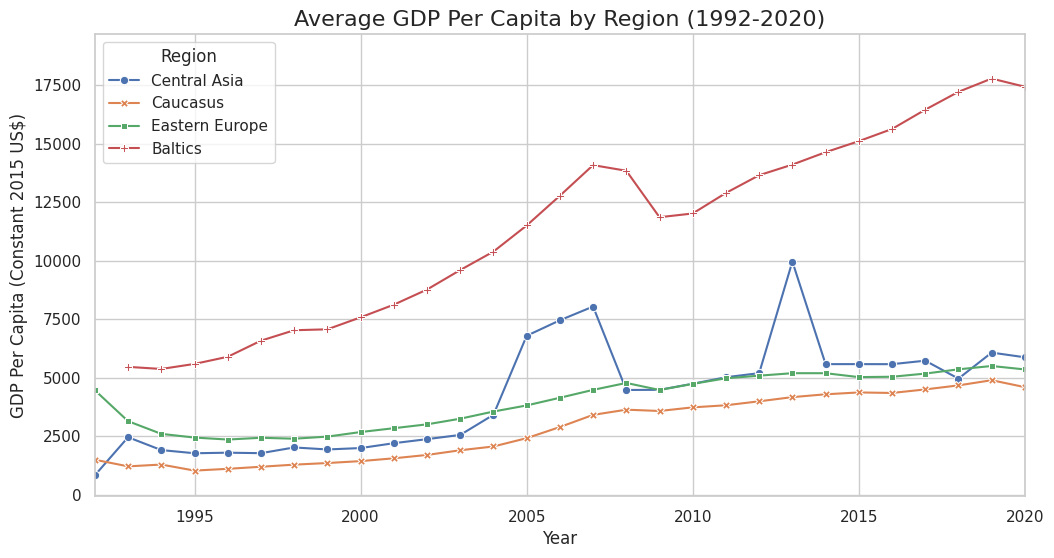

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='GDP_Per_Capita', hue='Region', style='Region', markers=True, dashes=False, ci=None)
plt.title('Average GDP Per Capita by Region (1992-2020)', fontsize=16)
plt.ylabel('GDP Per Capita (Constant 2015 US$)')
plt.xlim(1992, 2020)
plt.show()


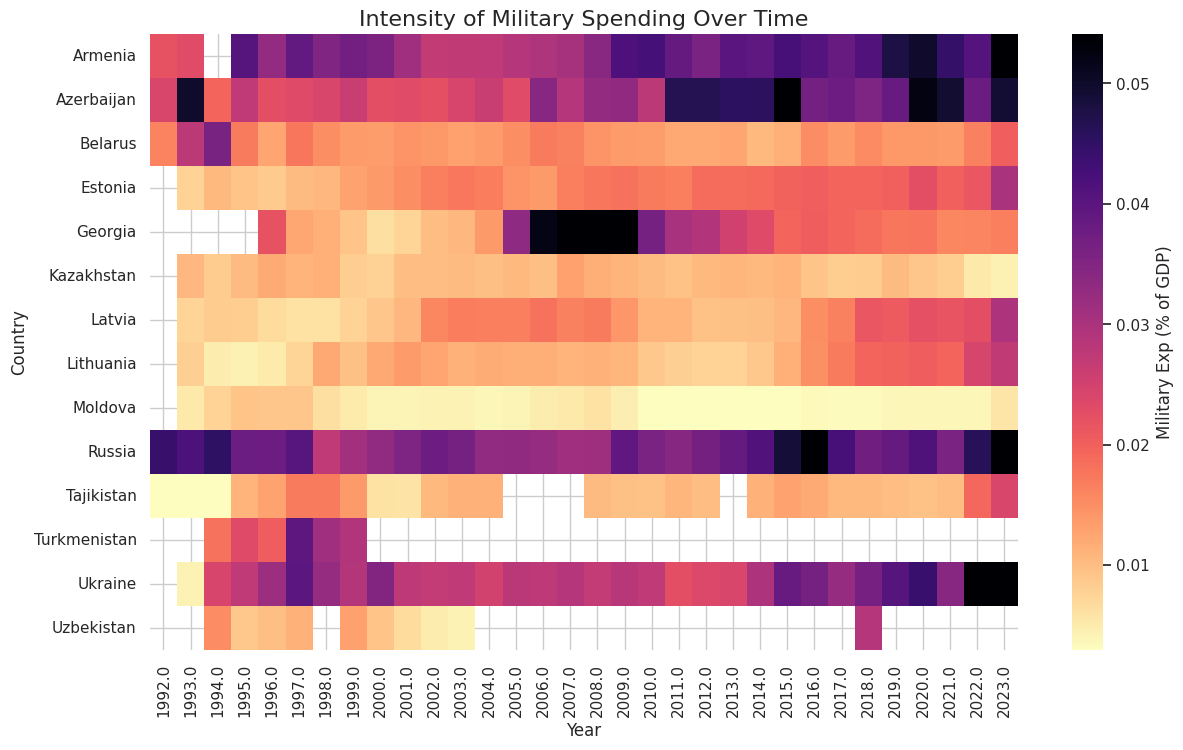

In [18]:
# Pivot data for heatmap
pivot_mil = df.pivot_table(index='Country', columns='Year', values='Military_Exp_Percent_GDP')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_mil, cmap="magma_r", robust=True, cbar_kws={'label': 'Military Exp (% of GDP)'})
plt.title('Intensity of Military Spending Over Time', fontsize=16)
plt.show()


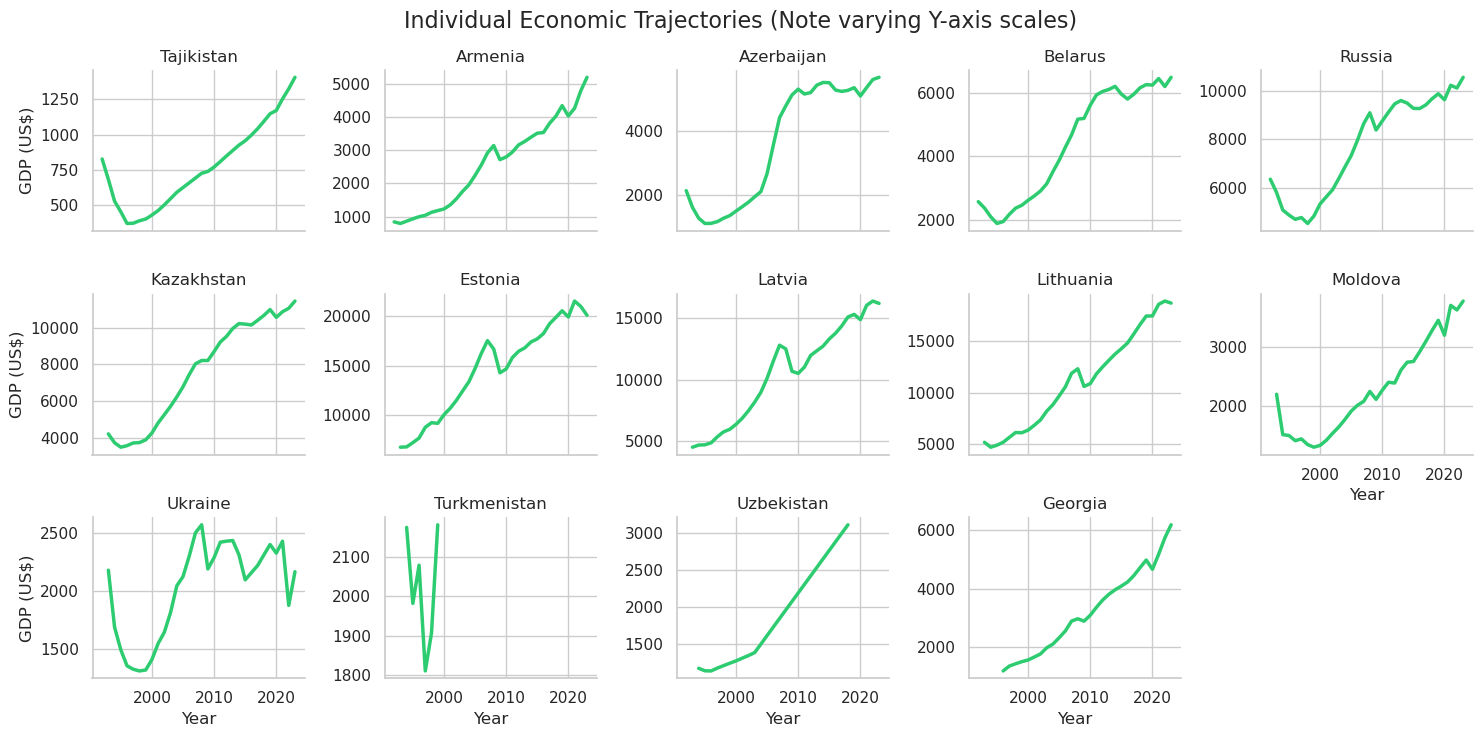

In [ ]:
g = sns.FacetGrid(df, col="Country", col_wrap=5, height=2.5, aspect=1.2, sharey=False)
g.map(sns.lineplot, "Year", "GDP_Per_Capita", linewidth=2.5, color="#2ecc71")
g.set_titles("{col_name}")
g.set_axis_labels("Year", "GDP (US$)")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Individual Economic Trajectories (Note varying Y-axis scales)', fontsize=16)
plt.show()


/tmp/ipykernel_435/3880570936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Period', y='GDP_Per_Capita', order=order, palette="vlag")


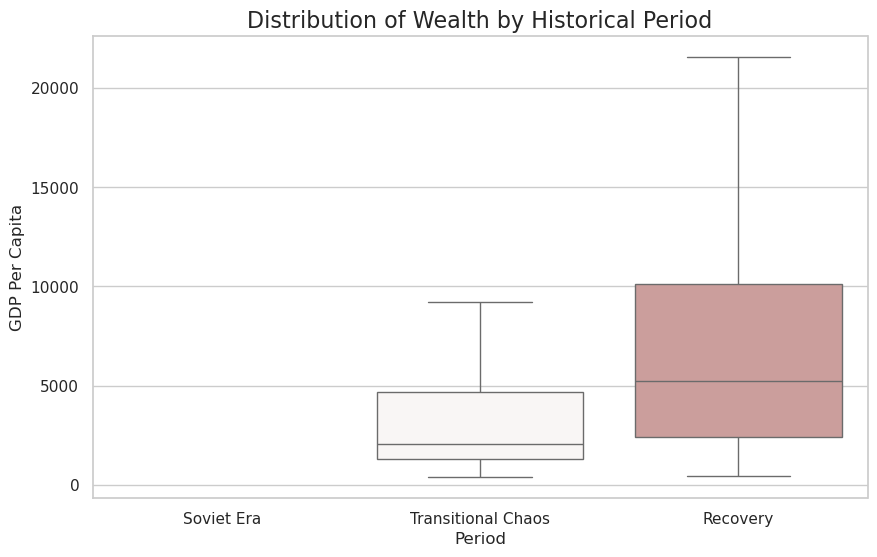

In [ ]:
order = ['Soviet Era', 'Transitional Chaos', 'Recovery'] # Define logical order
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Period', y='GDP_Per_Capita', order=order, palette="vlag")
plt.title('Distribution of Wealth by Historical Period', fontsize=16)
plt.ylabel('GDP Per Capita')
plt.show()



/tmp/ipykernel_435/3228276234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Region', y='Military_Exp_Percent_GDP', inner="quartile", palette="muted")


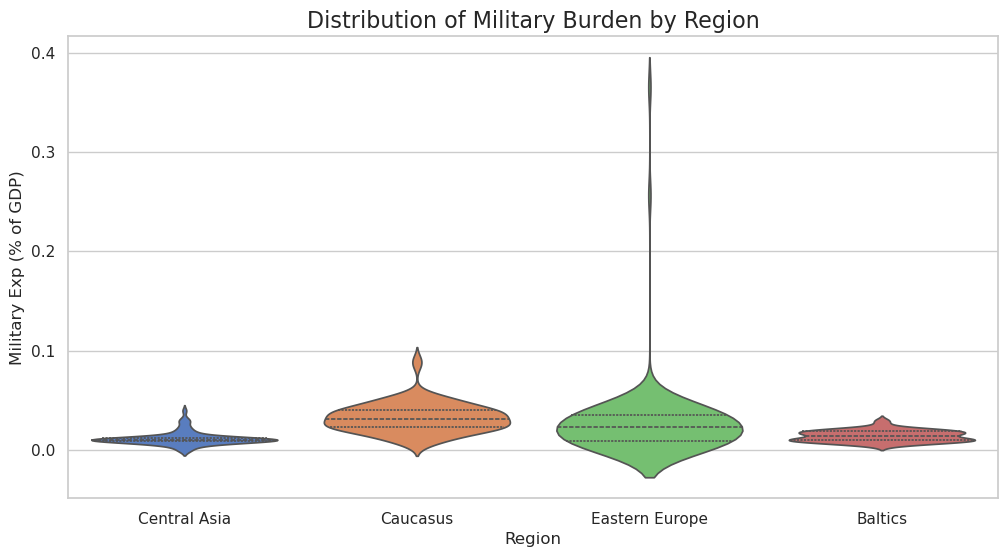

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Region', y='Military_Exp_Percent_GDP', inner="quartile", palette="muted")
plt.title('Distribution of Military Burden by Region', fontsize=16)
plt.ylabel('Military Exp (% of GDP)')
plt.show()


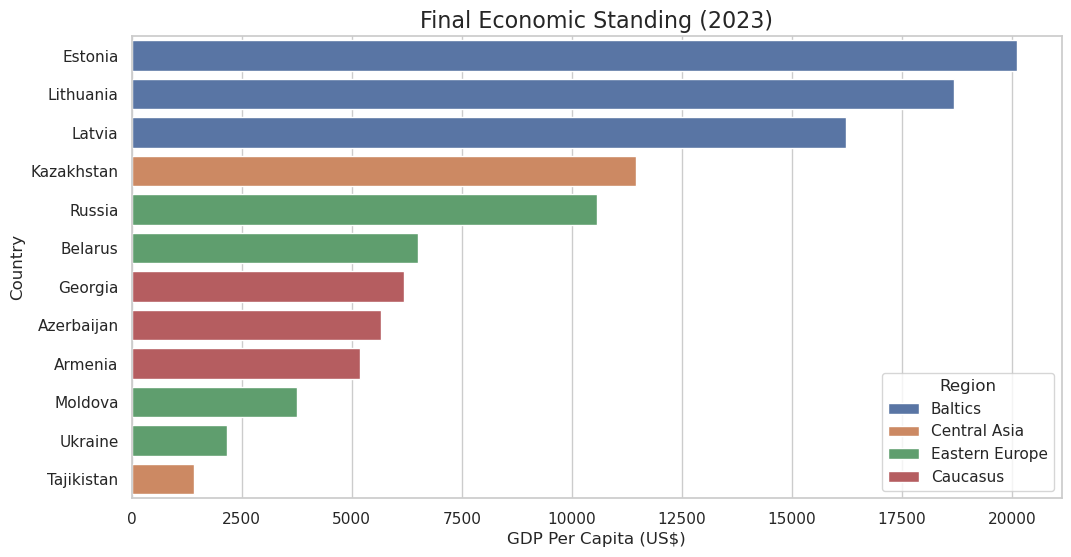

In [ ]:
latest_year = df['Year'].max()
latest_data = df[df['Year'] == latest_year].sort_values('GDP_Per_Capita', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=latest_data, x='GDP_Per_Capita', y='Country', hue='Region', dodge=False)
plt.title(f'Final Economic Standing ({int(latest_year)})', fontsize=16)
plt.xlabel('GDP Per Capita (US$)')
plt.show()


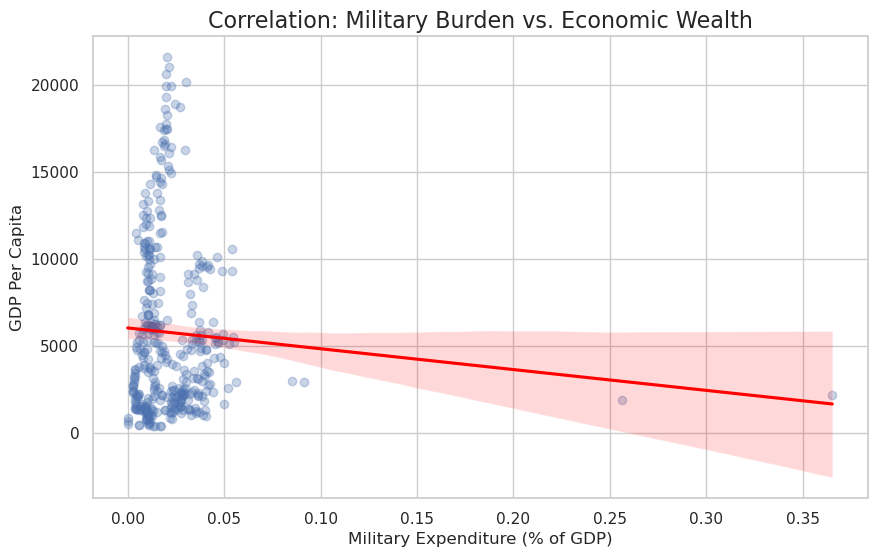

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Military_Exp_Percent_GDP', y='GDP_Per_Capita',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation: Military Burden vs. Economic Wealth', fontsize=16)
plt.xlabel('Military Expenditure (% of GDP)')
plt.ylabel('GDP Per Capita')
plt.show()


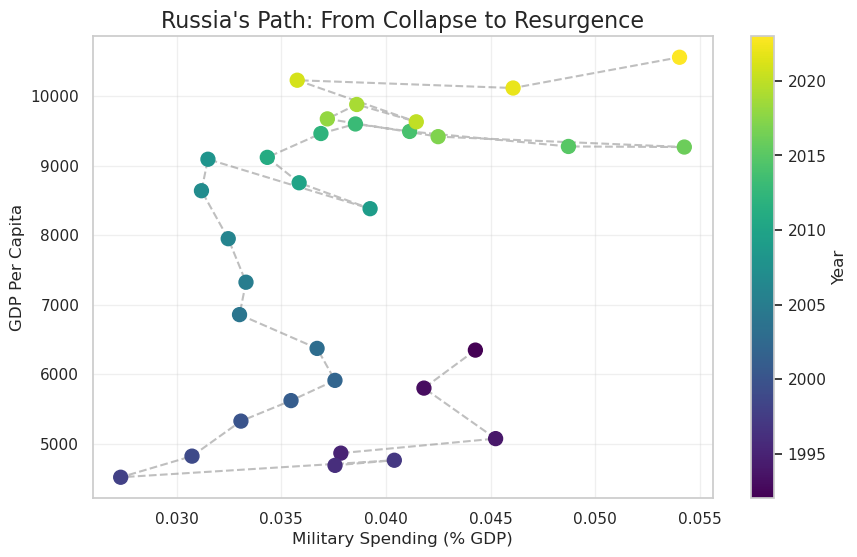

In [ ]:
russia = df[df['Country'] == 'Russia'].sort_values('Year')

plt.figure(figsize=(10, 6))
# Plot the path
plt.plot(russia['Military_Exp_Percent_GDP'], russia['GDP_Per_Capita'], color='grey', linestyle='--', alpha=0.5)
# Plot the points with color by year
points = plt.scatter(russia['Military_Exp_Percent_GDP'], russia['GDP_Per_Capita'],
                     c=russia['Year'], cmap='viridis', s=100, zorder=10)
plt.colorbar(points, label='Year')
plt.title("Russia's Path: From Collapse to Resurgence", fontsize=16)
plt.xlabel('Military Spending (% GDP)')
plt.ylabel('GDP Per Capita')
plt.grid(True, alpha=0.3)
plt.show()


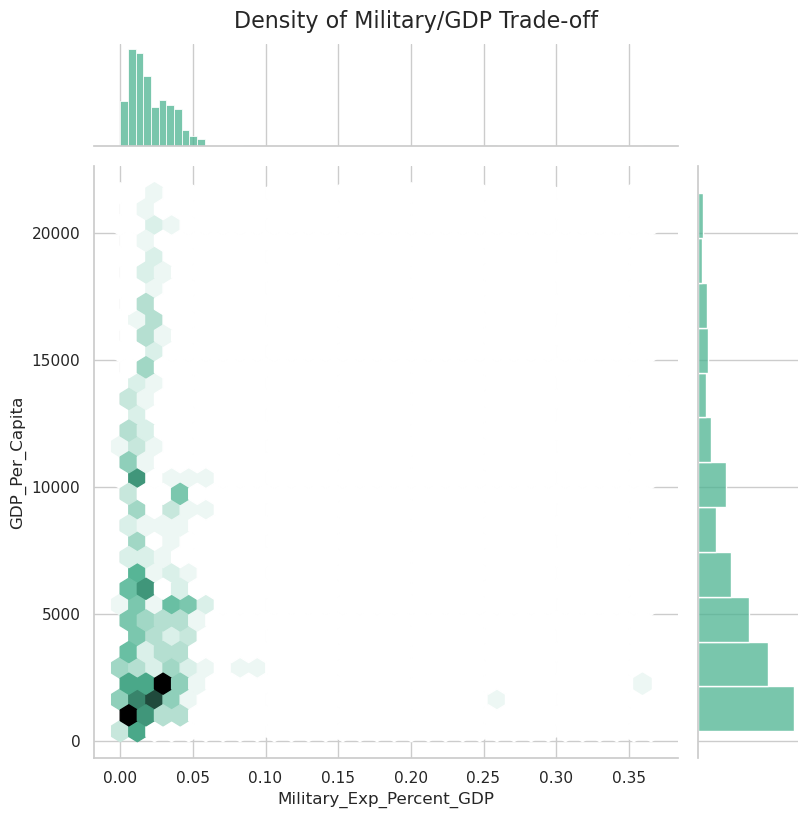

In [ ]:
g = sns.jointplot(data=df, x="Military_Exp_Percent_GDP", y="GDP_Per_Capita",
                  kind="hex", color="#4CB391", height=8)
g.fig.suptitle('Density of Military/GDP Trade-off', y=1.02, fontsize=16)
plt.show()


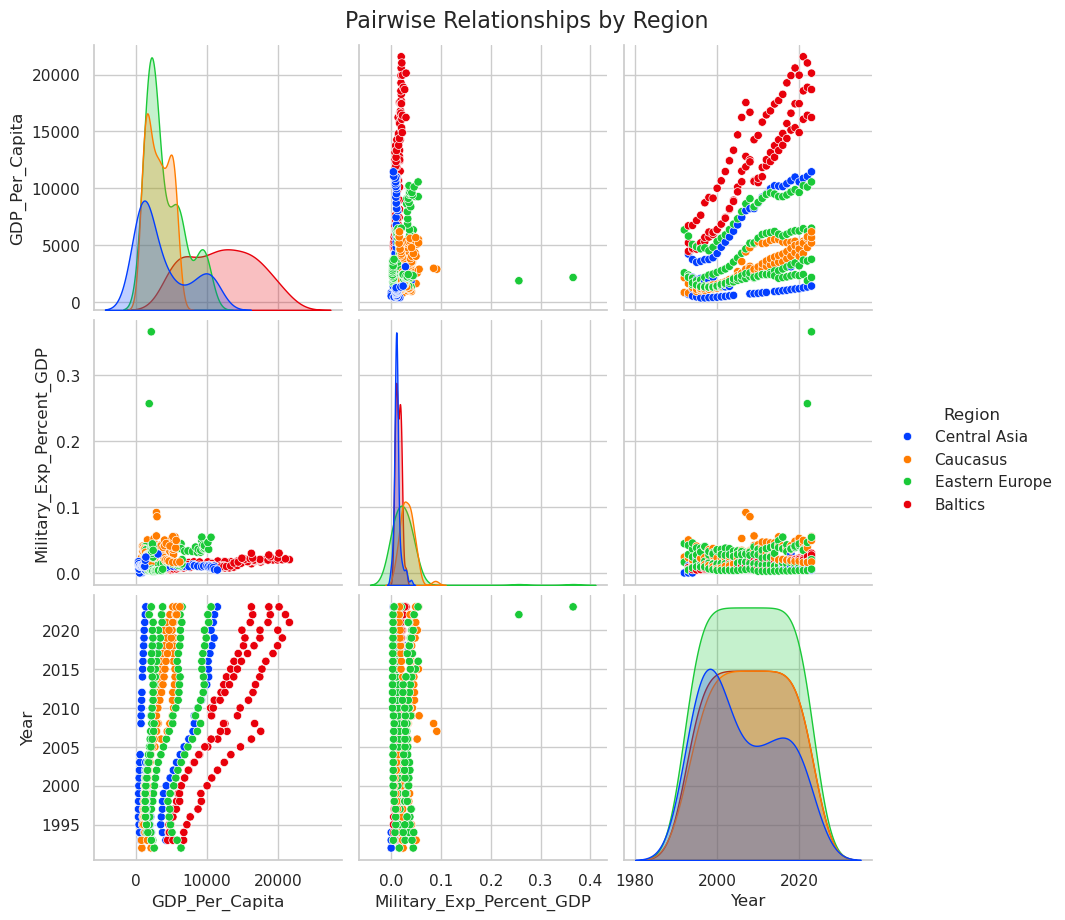

In [ ]:
# Select only numeric columns relevant for correlation
cols = ['GDP_Per_Capita', 'Military_Exp_Percent_GDP', 'Year']
sns.pairplot(df, vars=cols, hue='Region', palette='bright', height=3)
plt.suptitle('Pairwise Relationships by Region', y=1.02, fontsize=16)
plt.show()
